# Amazon Reviews Dataset Analysis

## Step 1: Load and Explore the Data

This notebook loads the Amazon Electronics reviews dataset from a compressed JSON Lines format (.json.gz). 
JSON Lines is a format where each line in the file is a separate, complete JSON object. We'll use Python's 
built-in `gzip` and `json` libraries to read this format efficiently.

In [1]:
import pandas as pd
import gzip
import json

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the JSON Lines Data

The data file is in JSON Lines format (`.json.gz`), which is a compressed text file where:
- Each line contains one complete JSON object
- Multiple JSON objects are separated by newlines
- The entire file is gzipped for compression

We'll:
1. Open the gzip file using `gzip.open()`
2. Read each line and parse it as JSON
3. Collect all parsed objects into a list
4. Convert the list to a pandas DataFrame

In [2]:
# File path
file_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/Electronics_5.json.gz"

# Read the gzip file and parse JSON Lines
data = []
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

# Convert to pandas DataFrame
df = pd.DataFrame(data)

print(f"Successfully loaded {len(data)} records from the compressed file!")
print(f"DataFrame created with shape: {df.shape}")

Successfully loaded 6739590 records from the compressed file!
DataFrame created with shape: (6739590, 12)


## Step 3: Preview and Inspect Dataset Structure

Now let's examine the dataset by:
- Viewing the first 5 rows with `df.head()`
- Checking the dataset dimensions (rows × columns) with `df.shape`
- Listing all column names with `df.columns`
- Getting data types and memory info with `df.info()`
- Computing descriptive statistics with `df.describe()`

In [3]:
# Display first 5 rows
print("=" * 80)
print("FIRST 5 ROWS OF THE DATASET:")
print("=" * 80)
print(df.head())

# Print dataset shape and column names
print("\n" + "=" * 80)
print("DATASET SHAPE AND COLUMNS:")
print("=" * 80)
print(f"Shape (rows, columns): {df.shape}")
print(f"\nColumn Names:\n{list(df.columns)}")

# Display dataset info
print("\n" + "=" * 80)
print("DATASET INFO:")
print("=" * 80)
print(df.info())

# Display descriptive statistics
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS:")
print("=" * 80)
print(df.describe())

FIRST 5 ROWS OF THE DATASET:
   overall vote  verified   reviewTime      reviewerID        asin  \
0      5.0   67      True  09 18, 1999   AAP7PPBU72QFM  0151004714   
1      3.0    5      True  10 23, 2013  A2E168DTVGE6SV  0151004714   
2      5.0    4     False   09 2, 2008  A1ER5AYS3FQ9O3  0151004714   
3      5.0   13     False   09 4, 2000  A1T17LMQABMBN5  0151004714   
4      3.0    8      True   02 4, 2000  A3QHJ0FXK33OBE  0151004714   

                            style      reviewerName  \
0       {'Format:': ' Hardcover'}      D. C. Carrad   
1  {'Format:': ' Kindle Edition'}               Evy   
2       {'Format:': ' Paperback'}             Kcorn   
3       {'Format:': ' Hardcover'}   Caf Girl Writes   
4       {'Format:': ' Hardcover'}  W. Shane Schmidt   

                                          reviewText  \
0  This is the best novel I have read in 2 or 3 y...   
1  Pages and pages of introspection, in the style...   
2  This is the kind of novel to read when you hav..

## Step 4: Check for Missing Values

Missing or null values can significantly impact data analysis. We'll:
- Count null values in each column using `df.isnull().sum()`
- Calculate the percentage of missing data for each column
- Visualize which columns have missing data
- Identify which rows have any missing values

In [4]:
# Count null values per column
print("=" * 80)
print("NULL VALUES COUNT PER COLUMN:")
print("=" * 80)
null_counts = df.isnull().sum()
print(null_counts)

# Calculate percentage of missing data
print("\n" + "=" * 80)
print("PERCENTAGE OF MISSING DATA PER COLUMN:")
print("=" * 80)
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

# Total null values in dataset
print("\n" + "=" * 80)
print("TOTAL NULL VALUES IN DATASET:")
print("=" * 80)
total_nulls = df.isnull().sum().sum()
print(f"Total null values: {total_nulls}")
print(f"Percentage of total data that is null: {(total_nulls / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# Check rows with any missing values
print("\n" + "=" * 80)
print("ROWS WITH ANY MISSING VALUES:")
print("=" * 80)
rows_with_nulls = df.isnull().any(axis=1).sum()
print(f"Number of rows with at least one null value: {rows_with_nulls}")
print(f"Number of rows with no missing values: {len(df) - rows_with_nulls}")

NULL VALUES COUNT PER COLUMN:
overall                 0
vote              5790916
verified                0
reviewTime              0
reviewerID              0
asin                    0
style             3192170
reviewerName          925
reviewText           1353
summary               812
unixReviewTime          0
image             6619632
dtype: int64

PERCENTAGE OF MISSING DATA PER COLUMN:
overall            0.000000
vote              85.923862
verified           0.000000
reviewTime         0.000000
reviewerID         0.000000
asin               0.000000
style             47.364454
reviewerName       0.013725
reviewText         0.020075
summary            0.012048
unixReviewTime     0.000000
image             98.220099
dtype: float64

TOTAL NULL VALUES IN DATASET:
Total null values: 15605808
Percentage of total data that is null: 19.30%

ROWS WITH ANY MISSING VALUES:
Number of rows with at least one null value: 6700840
Number of rows with no missing values: 38750


## Step 5: Save the DataFrame as CSV

Since loading the large compressed JSON file takes significant time, we'll save the DataFrame as a CSV file. 
This allows us to:
- Quickly reload the data in future sessions without decompressing the .json.gz file
- Share the processed data in a more universal format
- Avoid repeatedly parsing the entire JSON Lines file

Note: The CSV file will be stored in the `processed/` subdirectory of the data folder.

In [ ]:
import os

# Create the processed directory if it doesn't exist
processed_dir = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed"
os.makedirs(processed_dir, exist_ok=True)

# Define the CSV output path
csv_path = os.path.join(processed_dir, "electronics_reviews.csv")

# Save the DataFrame to CSV (without the index column)
df.to_csv(csv_path, index=False)

print(f"✓ DataFrame successfully saved to:")
print(f"  {csv_path}")
print(f"\nFile size: {os.path.getsize(csv_path) / (1024**2):.2f} MB")

## Step 6: Reload Data from CSV (Fast Loading)

In future sessions, you can skip the JSON Lines parsing step entirely and reload the data directly from the CSV file 
using `pd.read_csv()`. This is much faster than parsing the compressed JSON file. Simply run the cell below to reload 
the data:

**Option 1:** Load all data into memory (default)
- Use `df = pd.read_csv(csv_path)` for normal analysis

**Option 2:** Load data in chunks (for very large files)
- Use `chunksize` parameter if the file is too large to fit in memory

For this dataset, Option 1 should work fine. Here's how to do it:

In [ ]:
# Path to the CSV file
csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_reviews.csv"

# Reload the DataFrame from CSV (this is much faster than loading from JSON)
df_reloaded = pd.read_csv(csv_path)

print("✓ DataFrame successfully reloaded from CSV!")
print(f"\nDataFrame shape: {df_reloaded.shape}")
print(f"Columns: {list(df_reloaded.columns)}")
print(f"\nFirst 3 rows:")
print(df_reloaded.head(3))

# Verify it's the same data
print(f"\n✓ Data integrity check:")
print(f"  Original df shape: {df.shape}")
print(f"  Reloaded df shape: {df_reloaded.shape}")
print(f"  Shapes match: {df.shape == df_reloaded.shape}")

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_67053/2885784326.py:5: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reloaded = pd.read_csv(csv_path)


✓ DataFrame successfully reloaded from CSV!

DataFrame shape: (6739590, 12)
Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']

First 3 rows:
   overall vote  verified   reviewTime      reviewerID        asin  \
0      5.0   67      True  09 18, 1999   AAP7PPBU72QFM  0151004714   
1      3.0    5      True  10 23, 2013  A2E168DTVGE6SV  0151004714   
2      5.0    4     False   09 2, 2008  A1ER5AYS3FQ9O3  0151004714   

                            style  reviewerName  \
0       {'Format:': ' Hardcover'}  D. C. Carrad   
1  {'Format:': ' Kindle Edition'}           Evy   
2       {'Format:': ' Paperback'}         Kcorn   

                                          reviewText  \
0  This is the best novel I have read in 2 or 3 y...   
1  Pages and pages of introspection, in the style...   
2  This is the kind of novel to read when you hav...   

                                            

## Step 7: Load and Explore the Electronics Metadata Dataset

The metadata file contains product-level information for the Electronics category, including fields such as title, brand, and product description.
We will load the compressed JSON Lines file, convert it into a pandas DataFrame, inspect its structure, and then save it to CSV for faster reuse.


In [ ]:
meta_file_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/meta_Electronics.jsonl.gz"

meta_data = []
with gzip.open(meta_file_path, "rt", encoding="utf-8") as f:
    for line in f:
        meta_data.append(json.loads(line))

df_meta = pd.DataFrame(meta_data)
print(f"Successfully loaded {len(df_meta)} records from the metadata file!")
print(f"Metadata DataFrame shape: {df_meta.shape}")


### Metadata Dataset Preview and Inspection

Inspect the loaded metadata DataFrame by viewing the first rows, checking the shape and column names, and reviewing data types.


In [ ]:
print("=" * 80)
print("FIRST 5 ROWS OF THE METADATA DATASET:")
print("=" * 80)
print(df_meta.head())

print(" " + "=" * 80)
print("METADATA DATAFRAME SHAPE AND COLUMNS:")
print("=" * 80)
print(f"Shape (rows, columns): {df_meta.shape}")
print(f" Column Names: {list(df_meta.columns)}")

print(" " + "=" * 80)
print("METADATA DATAFRAME INFO:")
print("=" * 80)
print(df_meta.info())

print(" " + "=" * 80)
print("DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS:")
print("=" * 80)
print(df_meta.describe())


### Save Metadata as CSV

Saving the metadata DataFrame to CSV allows fast reloading in later sessions without parsing the compressed JSON file again.


In [ ]:
processed_dir = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed"
os.makedirs(processed_dir, exist_ok=True)
meta_csv_path = os.path.join(processed_dir, "meta_electronics.csv")
df_meta.to_csv(meta_csv_path, index=False)
print(f"✓ Metadata DataFrame successfully saved to:")
print(f"  {meta_csv_path}")
print(f" File size: {os.path.getsize(meta_csv_path) / (1024**2):.2f} MB")


### Reload Metadata from CSV

In future sessions, reload the metadata directly from `meta_electronics.csv` for much faster startup.


In [13]:
meta_csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/meta_electronics.csv"
df_meta_reloaded = pd.read_csv(meta_csv_path)
print(" ✓ Metadata DataFrame successfully reloaded from CSV!")
print(f" Reloaded DataFrame shape: {df_meta_reloaded.shape}")
print(f"Columns: {list(df_meta_reloaded.columns)}")
print(f" First 3 rows:")
print(df_meta_reloaded.head(3))

print(f" ✓ Data integrity check:")
print(f"  Original df_meta shape: {df_meta.shape}")
print(f"  Reloaded df_meta_reloaded shape: {df_meta_reloaded.shape}")
print(f"  Shapes match: {df_meta.shape == df_meta_reloaded.shape}")


 ✓ Metadata DataFrame successfully reloaded from CSV!
 Reloaded DataFrame shape: (275174, 16)
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
 First 3 rows:
     main_category                                              title  \
0  All Electronics             FS-1051 FATSHARK TELEPORTER V3 HEADSET   
1  All Electronics                      Ce-H22B12-S1 4Kx2K Hdmi 4Port   
2        Computers  Digi-Tatoo Decal Skin Compatible With MacBook ...   

   average_rating  rating_number  \
0             3.5              6   
1             5.0              1   
2             4.5            246   

                                            features  \
0                                                 []   
1         ['UPC: 662774021904', 'Weight: 0.600 lbs']   
2  ['WARNING: Please IDENTIFY MODEL NUMBER on the...   

           

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_97244/1029933988.py:2: DtypeWarning: Columns (0: price) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta_reloaded = pd.read_csv(meta_csv_path)


## Step 8: Quick Start — Load Processed Datasets

Skip the full processing pipeline and load both datasets directly from the saved CSV files.
This is the recommended entry point for all analysis sessions after the initial data preparation is complete.

In [ ]:
import pandas as pd
import numpy as np
import os
import gzip, json

# Load reviews dataset
reviews_csv = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_reviews.csv"
df = pd.read_csv(reviews_csv, low_memory=False)
print(f"Reviews loaded   : {df.shape[0]:,} rows  x  {df.shape[1]} columns")

# Load metadata — re-parse from source if the CSV is incomplete
meta_csv = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/meta_electronics.csv"
EXPECTED_META_ROWS = 1_610_012   # full metadata count from original JSONL

df_meta = pd.read_csv(meta_csv, low_memory=False)
print(f"Metadata from CSV: {df_meta.shape[0]:,} rows  x  {df_meta.shape[1]} columns")

if df_meta.shape[0] < EXPECTED_META_ROWS * 0.95:
    print(f"\n⚠  CSV is incomplete ({df_meta.shape[0]:,} vs expected ~{EXPECTED_META_ROWS:,} rows).")
    print("   Re-parsing from original JSONL source — this will take a few minutes…")
    meta_gz = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/meta_Electronics.jsonl.gz"
    meta_data = []
    with gzip.open(meta_gz, "rt", encoding="utf-8") as f:
        for line in f:
            meta_data.append(json.loads(line))
    df_meta = pd.DataFrame(meta_data)
    print(f"   Parsed {len(df_meta):,} records. Re-saving complete CSV…")
    df_meta.to_csv(meta_csv, index=False)
    print(f"   ✓ Saved to {meta_csv}")
else:
    print("   ✓ CSV is complete — no re-parse needed.")

print(f"\nReviews columns  : {list(df.columns)}")
print(f"Metadata columns : {list(df_meta.columns)}")

## Step 9: EDA — Reviews Dataset

Quick exploratory analysis covering rating distribution, verified purchase breakdown, review volume over time, and missing value profile.

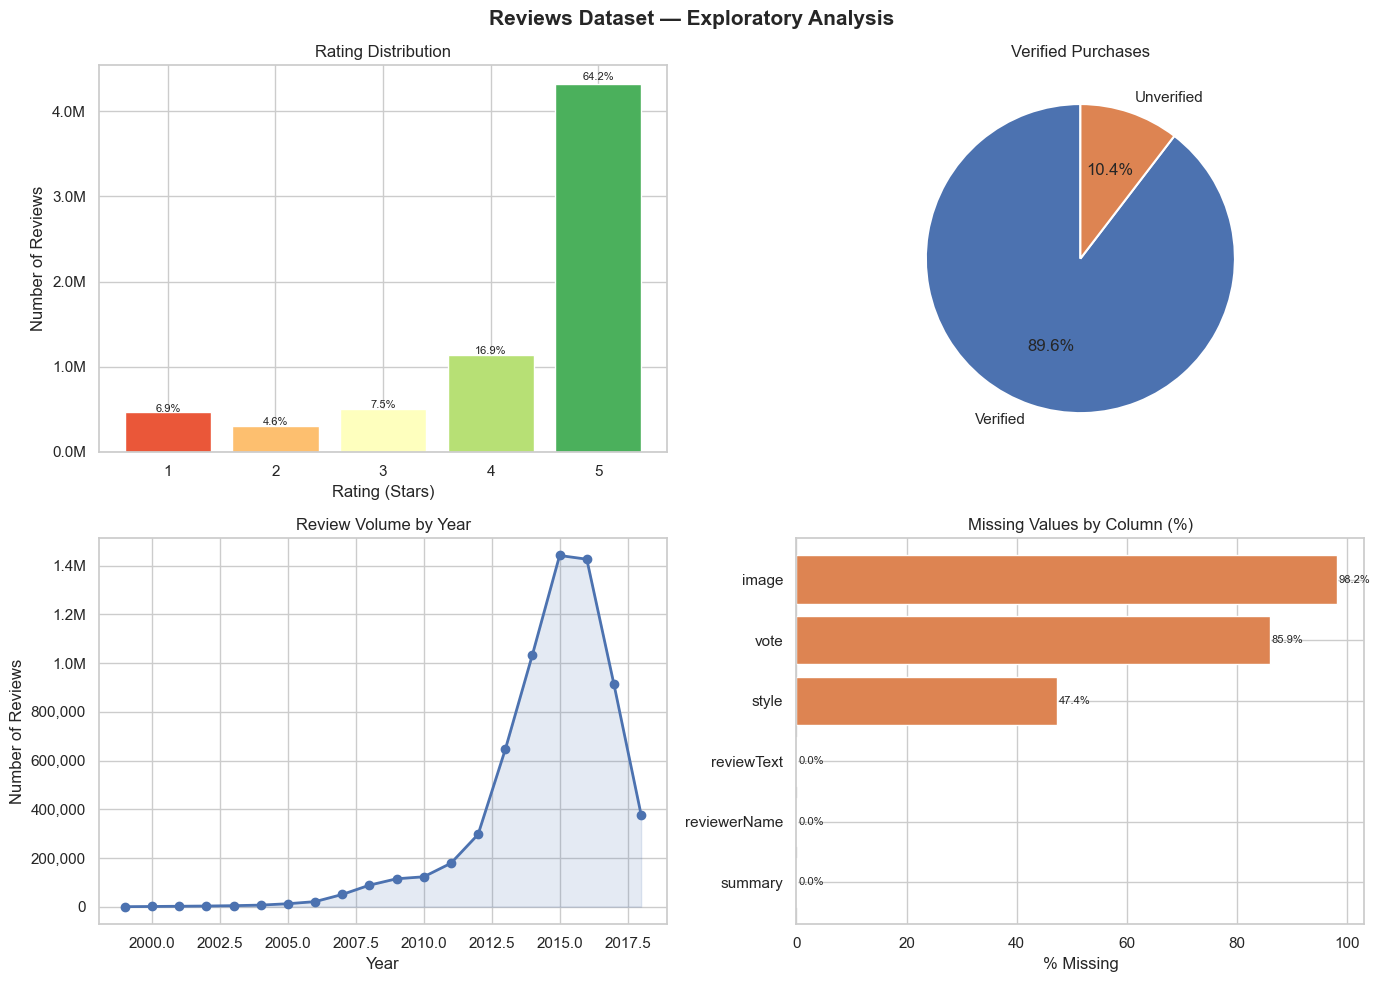

=== Reviews Dataset Summary ===
Total reviews      : 6,739,590
Unique products    : 160,052
Unique reviewers   : 728,719
Date range         : 1999 – 2018
Average rating     : 4.27 ± 1.20
Verified purchase %: 89.6%
Reviews with text  : 6,737,950  (100.0%)


In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Reviews Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Rating distribution
rating_counts = df["overall"].value_counts().sort_index()
colors = sns.color_palette("RdYlGn", 5)
bars = axes[0, 0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating (Stars)")
axes[0, 0].set_ylabel("Number of Reviews")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, val in zip(bars, rating_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                    f"{val/len(df)*100:.1f}%", ha="center", fontsize=8)

# 2. Verified vs Unverified purchase
v_counts = df["verified"].value_counts()
axes[0, 1].pie(v_counts, labels=["Verified", "Unverified"] if v_counts.index[0] else ["Unverified", "Verified"],
               autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], startangle=90,
               wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0, 1].set_title("Verified Purchases")

# 3. Review volume over time
df_temp = df.copy()
df_temp["year"] = pd.to_datetime(df_temp["unixReviewTime"], unit="s").dt.year
year_counts = df_temp["year"].value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, marker="o", linewidth=2, color="#4C72B0")
axes[1, 0].fill_between(year_counts.index, year_counts.values, alpha=0.15, color="#4C72B0")
axes[1, 0].set_title("Review Volume by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number of Reviews")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x):,}"))

# 4. Missing value summary (columns with any missing data)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
axes[1, 1].barh(missing.index, missing.values / len(df) * 100, color="#DD8452")
axes[1, 1].set_title("Missing Values by Column (%)")
axes[1, 1].set_xlabel("% Missing")
for i, v in enumerate(missing.values):
    axes[1, 1].text(v / len(df) * 100 + 0.3, i, f"{v/len(df)*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("=== Reviews Dataset Summary ===")
df_temp["year"] = pd.to_datetime(df_temp["unixReviewTime"], unit="s").dt.year
print(f"Total reviews      : {len(df):,}")
print(f"Unique products    : {df['asin'].nunique():,}")
print(f"Unique reviewers   : {df['reviewerID'].nunique():,}")
print(f"Date range         : {df_temp['year'].min()} – {df_temp['year'].max()}")
print(f"Average rating     : {df['overall'].mean():.2f} ± {df['overall'].std():.2f}")
print(f"Verified purchase %: {df['verified'].mean()*100:.1f}%")
print(f"Reviews with text  : {df['reviewText'].notna().sum():,}  ({df['reviewText'].notna().mean()*100:.1f}%)")

## Step 10: EDA — Metadata Dataset

Explore the product catalogue: check available fields, missing values, price distribution, and top brands.

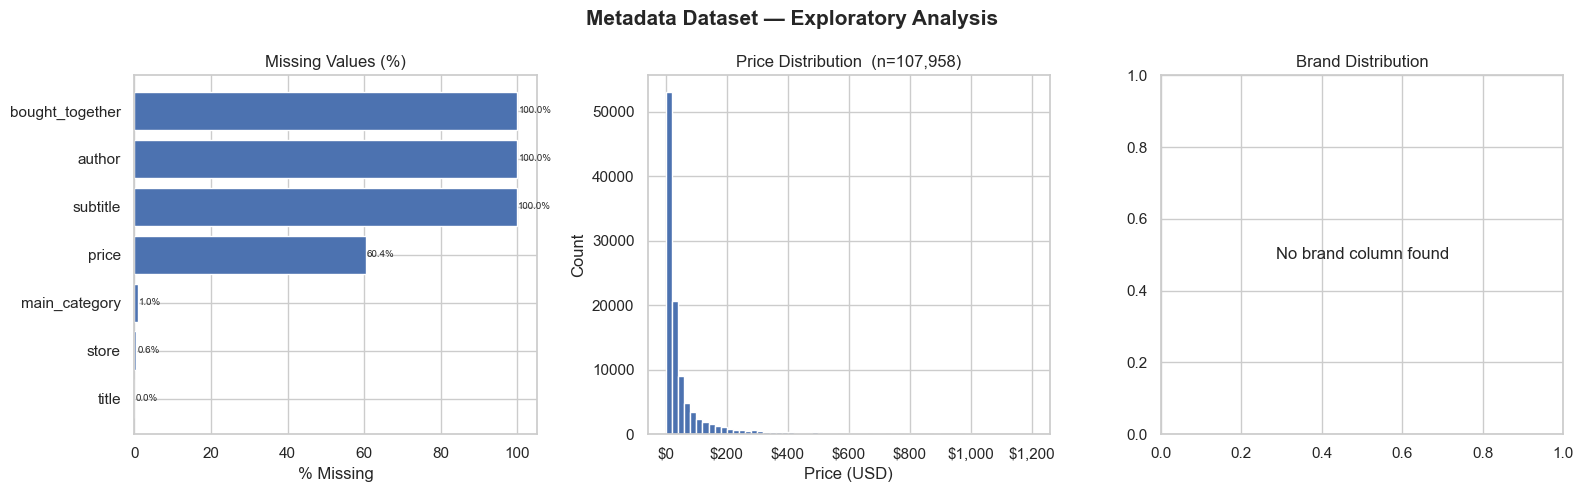

=== Metadata Dataset Summary ===
Total products : 275,174
Columns        : ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Metadata Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Missing values
meta_missing = df_meta.isnull().sum()
meta_missing = meta_missing[meta_missing > 0].sort_values(ascending=True)
if not meta_missing.empty:
    axes[0].barh(meta_missing.index, meta_missing.values / len(df_meta) * 100, color="#4C72B0")
    axes[0].set_title("Missing Values (%)")
    axes[0].set_xlabel("% Missing")
    for i, v in enumerate(meta_missing.values):
        axes[0].text(v / len(df_meta) * 100 + 0.3, i, f"{v/len(df_meta)*100:.1f}%", va="center", fontsize=7)
else:
    axes[0].text(0.5, 0.5, "No missing values", ha="center", va="center")
    axes[0].set_title("Missing Values")

# 2. Price distribution
if "price" in df_meta.columns:
    prices = pd.to_numeric(
        df_meta["price"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce"
    ).dropna()
    prices = prices[(prices > 0) & (prices < prices.quantile(0.99))]
    axes[1].hist(prices, bins=60, color="#4C72B0", edgecolor="white")
    axes[1].set_title(f"Price Distribution  (n={len(prices):,})")
    axes[1].set_xlabel("Price (USD)")
    axes[1].set_ylabel("Count")
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
else:
    axes[1].text(0.5, 0.5, "No price column", ha="center", va="center")
    axes[1].set_title("Price Distribution")

# 3. Top brands by product count
brand_col_meta = next((c for c in df_meta.columns if c.lower() in ("brand", "brand_name")), None)
if brand_col_meta:
    top_brands = df_meta[brand_col_meta].value_counts().dropna().head(15)
    axes[2].barh(top_brands.index[::-1], top_brands.values[::-1], color="#55A868")
    axes[2].set_title("Top 15 Brands by Product Count")
    axes[2].set_xlabel("Number of Products")
    axes[2].tick_params(axis="y", labelsize=7)
else:
    axes[2].text(0.5, 0.5, "No brand column found", ha="center", va="center")
    axes[2].set_title("Brand Distribution")

plt.tight_layout()
plt.show()

print("=== Metadata Dataset Summary ===")
print(f"Total products : {len(df_meta):,}")
print(f"Columns        : {list(df_meta.columns)}")
if brand_col_meta:
    print(f"Unique brands  : {df_meta[brand_col_meta].nunique():,}")
    asin_overlap = df_meta["asin"].isin(df["asin"]).sum()
    print(f"ASINs also in reviews: {asin_overlap:,}  ({asin_overlap/len(df_meta)*100:.1f}% of products)")

## Step 11: Merge Reviews with Product Metadata

Join the reviews and metadata DataFrames on `asin` (product ID) using a **left join** to preserve all reviews.
This attaches the product title, brand, and category to every review row.

In [ ]:
# ── Diagnostics: find the right join key ─────────────────────────────────────
print("=== Join Key Diagnostics ===\n")
print(f"Review ASIN sample  : {df['asin'].head(5).tolist()}")

asin_candidates = [c for c in df_meta.columns if "asin" in c.lower()]
print(f"Metadata ASIN cols  : {asin_candidates}")
for col in asin_candidates:
    sample = df_meta[col].dropna().head(5).tolist()
    raw_overlap = df_meta[col].isin(df["asin"]).sum()
    clean_overlap = df_meta[col].astype(str).str.strip().isin(df["asin"].str.strip()).sum()
    print(f"\n  '{col}'")
    print(f"    sample          : {sample}")
    print(f"    overlap (raw)   : {raw_overlap:,}  ({raw_overlap/len(df_meta)*100:.1f}% of meta products)")
    print(f"    overlap (strip) : {clean_overlap:,}  ({clean_overlap/len(df_meta)*100:.1f}% of meta products)")

# ── Pick the best join column ─────────────────────────────────────────────────
best_col = max(
    asin_candidates,
    key=lambda c: df_meta[c].astype(str).str.strip().isin(df["asin"].str.strip()).sum()
)
print(f"\nBest join key: '{best_col}'")

# ── Build slim metadata and merge ─────────────────────────────────────────────
meta_keep = [best_col]
for candidate in ["title", "store", "price", "main_category", "categories", "average_rating"]:
    if candidate in df_meta.columns:
        meta_keep.append(candidate)

df_meta_slim = (
    df_meta[meta_keep]
    .copy()
    .assign(**{best_col: df_meta[best_col].astype(str).str.strip()})
    .rename(columns={best_col: "asin", "store": "brand", "main_category": "category"})
    .drop_duplicates(subset="asin")
)

df_clean = df.copy()
df_clean["asin"] = df_clean["asin"].str.strip()

df_merged = df_clean.merge(df_meta_slim, on="asin", how="left")

# ── Report ─────────────────────────────────────────────────────────────────────
matched   = df_merged["title"].notna().sum() if "title" in df_merged.columns else \
            df_merged["asin"].isin(df_meta_slim["asin"]).sum()
unmatched = len(df_merged) - matched

print(f"\n=== Merge Results ===")
print(f"Reviews total       : {len(df):,}")
print(f"Matched to metadata : {matched:,}  ({matched/len(df_merged)*100:.1f}%)")
print(f"Unmatched           : {unmatched:,}  ({unmatched/len(df_merged)*100:.1f}%)")
print(f"Merged shape        : {df_merged.shape}")
print(f"Merged columns      : {list(df_merged.columns)}")

title_col = next((c for c in df_merged.columns if c.lower() == "title"), None)
show = ["overall", "asin"] + ([title_col] if title_col else []) + \
       (["brand"] if "brand" in df_merged.columns else []) + ["reviewText"]
df_merged[show].dropna(subset=[title_col] if title_col else []).head(5)

## Step 12: EDA — Combined Dataset

Analyse the merged data to understand how ratings relate to products, brands, and review patterns over time.

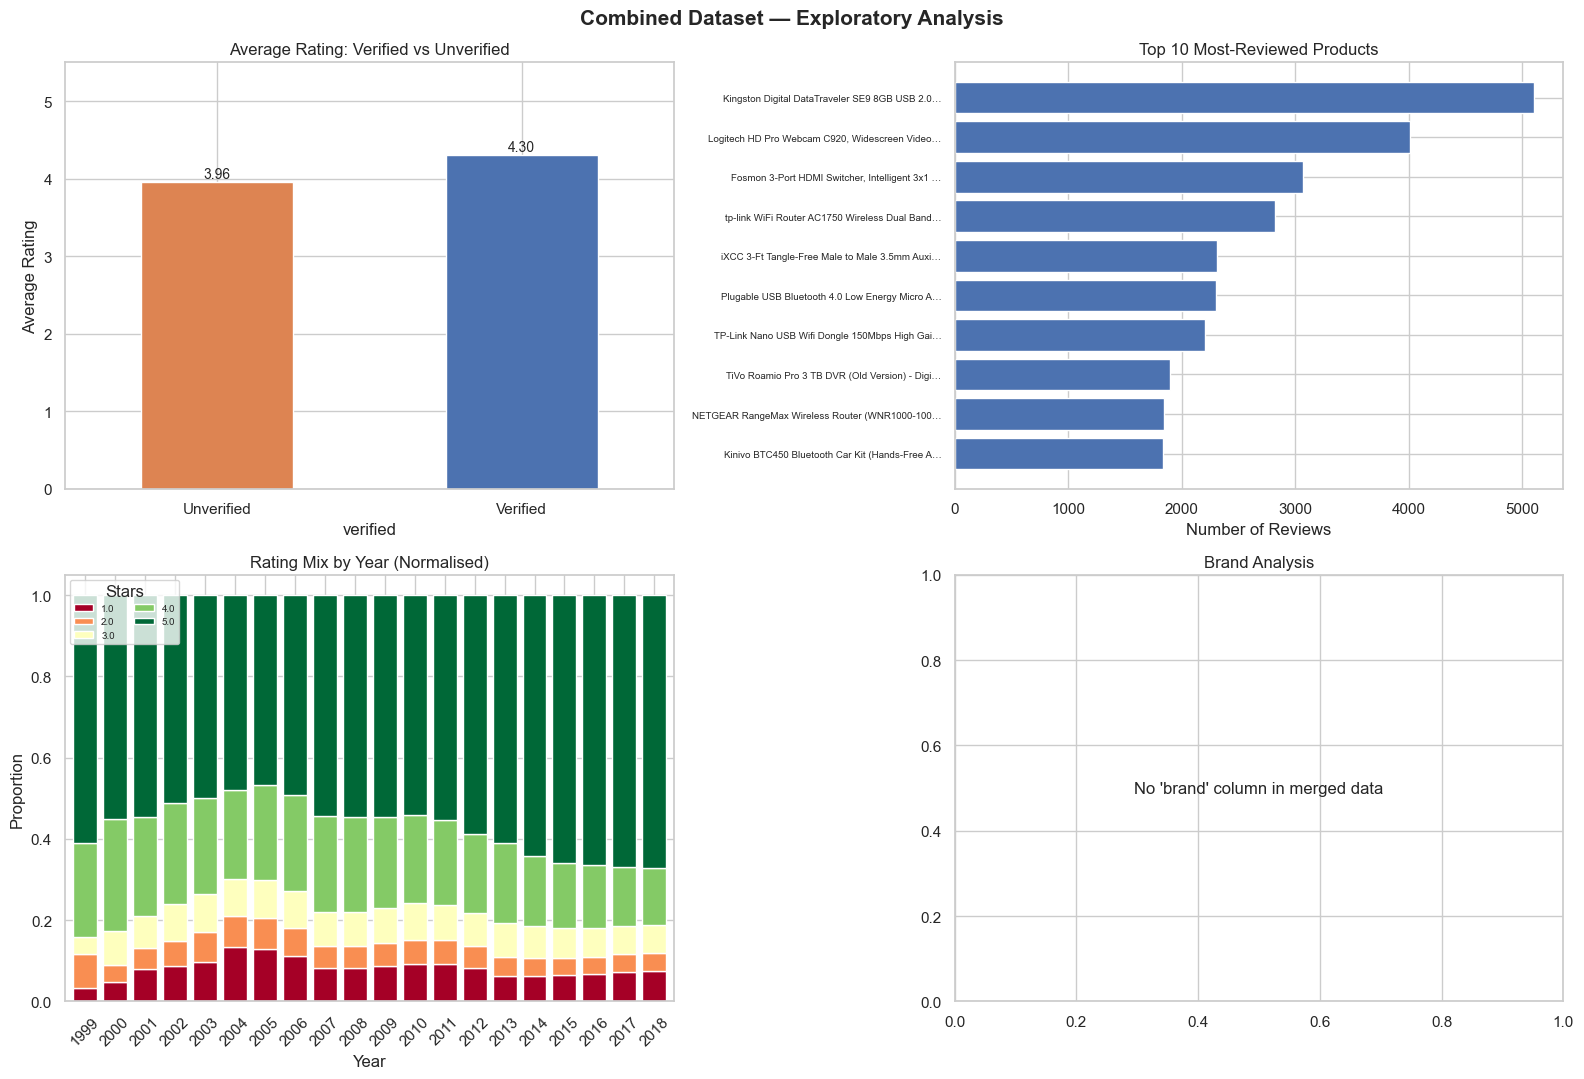

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Derive year locally — df_merged doesn't have it yet (added in Step 13)
year_series = pd.to_datetime(df_merged["unixReviewTime"], unit="s").dt.year

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Combined Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Average rating: verified vs unverified
avg_by_verified = (
    df_merged.groupby("verified")["overall"]
    .mean()
    .rename(index={True: "Verified", False: "Unverified"})
)
avg_by_verified.plot(kind="bar", ax=axes[0, 0], color=["#DD8452", "#4C72B0"], rot=0)
axes[0, 0].set_title("Average Rating: Verified vs Unverified")
axes[0, 0].set_ylabel("Average Rating")
axes[0, 0].set_ylim(0, 5.5)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.2f}",
                        (p.get_x() + p.get_width() / 2, p.get_height() + 0.05),
                        ha="center", fontsize=10)

# 2. Top 10 most-reviewed products
title_col = next((c for c in df_merged.columns if c.lower() == "title"), "asin")
top_products = df_merged.groupby(title_col).size().nlargest(10)
labels = [str(t)[:45] + "…" if len(str(t)) > 45 else str(t) for t in top_products.index[::-1]]
axes[0, 1].barh(labels, top_products.values[::-1], color="#4C72B0")
axes[0, 1].set_title("Top 10 Most-Reviewed Products")
axes[0, 1].set_xlabel("Number of Reviews")
axes[0, 1].tick_params(axis="y", labelsize=7)

# 3. Normalised rating mix by year
pivot_df = df_merged.copy()
pivot_df["year"] = year_series.values
pivot = pivot_df.groupby(["year", "overall"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.plot(kind="bar", stacked=True, ax=axes[1, 0], colormap="RdYlGn", width=0.8)
axes[1, 0].set_title("Rating Mix by Year (Normalised)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(title="Stars", loc="upper left", fontsize=7, ncol=2)

# 4. Average rating by brand (top 10 by volume)
brand_col = next((c for c in df_merged.columns if c.lower() == "brand"), None)
if brand_col:
    brand_stats = (
        df_merged.groupby(brand_col)
        .agg(count=("overall", "size"), avg_rating=("overall", "mean"))
        .query("count >= 500")
        .nlargest(10, "count")
    )
    axes[1, 1].barh(brand_stats.index[::-1], brand_stats["avg_rating"][::-1], color="#55A868")
    axes[1, 1].set_title("Avg Rating — Top 10 Brands (≥500 reviews)")
    axes[1, 1].set_xlabel("Average Rating")
    axes[1, 1].set_xlim(1, 5.5)
    for i, (_, row) in enumerate(brand_stats[::-1].iterrows()):
        axes[1, 1].text(row["avg_rating"] + 0.05, i, f"{row['avg_rating']:.2f}", va="center", fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, "No 'brand' column in merged data", ha="center", va="center",
                    transform=axes[1, 1].transAxes)
    axes[1, 1].set_title("Brand Analysis")

plt.tight_layout()
plt.show()

## Step 13: Feature Engineering for NLP

Build a clean, feature-rich DataFrame (`df_nlp`) ready for downstream NLP tasks — sentiment analysis, topic modelling, text classification, etc.

| Feature | Description |
|---|---|
| `clean_text` | Lowercased, HTML-stripped, punctuation-normalised `reviewText` |
| `combined_text` | `summary` + `reviewText` joined — richer context for embeddings |
| `char_count` | Raw character length of `reviewText` |
| `word_count` | Token count of cleaned review |
| `avg_word_len` | Average token length (vocabulary complexity proxy) |
| `vote_count` | Numeric helpfulness votes (NaN → 0) |
| `is_verified` | Verified purchase cast to 0/1 int |
| `year` / `month` | Time features from unix timestamp |
| `review_age_days` | Days since review (relative to latest review in dataset) |
| `sentiment_label` | `positive` (4–5★) · `neutral` (3★) · `negative` (1–2★) |

In [27]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)         # strip HTML tags
    text = re.sub(r"[^\w\s']", " ", text)         # keep word chars, spaces, apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_nlp = df_merged.copy()

# --- Text features ---
df_nlp["clean_text"]     = df_nlp["reviewText"].apply(clean_text)
df_nlp["combined_text"]  = (
    df_nlp["summary"].fillna("") + " " + df_nlp["reviewText"].fillna("")
).str.strip().apply(clean_text)
df_nlp["char_count"]     = df_nlp["reviewText"].fillna("").str.len()
df_nlp["word_count"]     = df_nlp["clean_text"].str.split().str.len().fillna(0).astype(int)
df_nlp["avg_word_len"]   = df_nlp["clean_text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.strip() else 0
)

# --- Engagement features ---
df_nlp["vote_count"]     = pd.to_numeric(df_nlp["vote"], errors="coerce").fillna(0).astype(int)
df_nlp["is_verified"]    = df_nlp["verified"].astype(int)

# --- Time features ---
review_dt                = pd.to_datetime(df_nlp["unixReviewTime"], unit="s")
df_nlp["year"]           = review_dt.dt.year
df_nlp["month"]          = review_dt.dt.month
max_ts                   = df_nlp["unixReviewTime"].max()
df_nlp["review_age_days"] = ((max_ts - df_nlp["unixReviewTime"]) / 86400).astype(int)

# --- Sentiment label (3-class) ---
df_nlp["sentiment_label"] = df_nlp["overall"].map(
    lambda r: "positive" if r >= 4 else ("neutral" if r == 3 else "negative")
)

# Drop columns not useful for NLP
drop_cols = [c for c in ["style", "image", "reviewTime", "vote"] if c in df_nlp.columns]
df_nlp.drop(columns=drop_cols, inplace=True)

print("=== NLP-Ready DataFrame ===")
print(f"Shape: {df_nlp.shape}")
print(f"\nEngineered features:")
eng_cols = ["clean_text", "combined_text", "char_count", "word_count", "avg_word_len",
            "vote_count", "is_verified", "year", "month", "review_age_days", "sentiment_label"]
for col in eng_cols:
    print(f"  {col:<22} dtype={df_nlp[col].dtype}")

print("\nSentiment label distribution:")
print(df_nlp["sentiment_label"].value_counts().rename("count").to_frame()
      .assign(pct=lambda x: (x["count"] / len(df_nlp) * 100).round(1)).to_string())

print("\nWord count statistics (reviewText):")
print(df_nlp["word_count"].describe().round(1).to_string())

# Sample row
sample = df_nlp[df_nlp["word_count"] > 20].iloc[0]
print(f"\nSample NLP-ready row:")
print(f"  Rating        : {sample['overall']}")
print(f"  Sentiment     : {sample['sentiment_label']}")
print(f"  Word count    : {sample['word_count']}")
print(f"  Clean text    : {sample['clean_text'][:120]}…")
if "title" in df_nlp.columns:
    print(f"  Product title : {str(sample['title'])[:80]}")

: 

In [ ]:
nlp_csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_nlp_ready.csv"
df_nlp.to_csv(nlp_csv_path, index=False)
print(f"✓ NLP-ready DataFrame saved to:")
print(f"  {nlp_csv_path}")
print(f"  Size: {os.path.getsize(nlp_csv_path) / (1024**2):.1f} MB")
print(f"\nQuick-load in future sessions:")
print(f"  df_nlp = pd.read_csv('{nlp_csv_path}', low_memory=False)")